In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from random import sample

In [22]:
data_directory = '/home/danielb/Desktop/Coding Projects/lidar_object_tracking/data/raw/'

frame_dict = {}
for dir in os.scandir(data_directory+'001/lidar/'):
    with open(dir, 'rb') as file:
        try:
            frame_dict[int(dir.name[0:2])] = pd.DataFrame(pickle.load(file))
        except:
            pass

frame_dict = dict(sorted(frame_dict.items()))

frame_dict[0].head()

/tmp/ipykernel_42811/1593697905.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  frame_dict[int(dir.name[0:2])] = pd.DataFrame(pickle.load(file))


,x,y,z,i,t,d
index,,,,,,
0,-58.457199,-61.269268,2.881014,39.0,1.557540e+09,0
1,-71.572182,-74.840317,1.279183,9.0,1.557540e+09,0
2,-42.442833,-44.357426,0.426503,56.0,1.557540e+09,0
3,-31.749357,-33.156342,-0.025245,3.0,1.557540e+09,0
4,-9.920758,-10.442794,1.010120,0.0,1.557540e+09,0


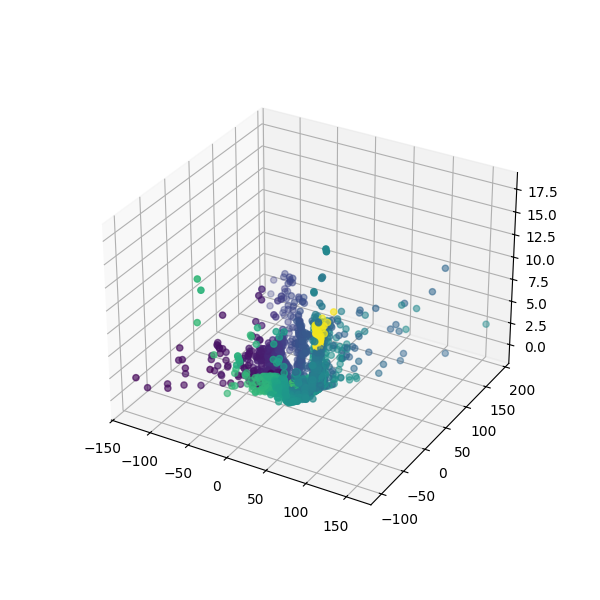

In [30]:
sub_sample = sample(range(len(frame_dict[0])), 2500)

sampled_frame = frame_dict[0].loc[sub_sample]

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(projection = '3d')

ax.scatter(sampled_frame['x'], sampled_frame['y'],sampled_frame['z'], c = sampled_frame['t'], cmap = 'viridis')

%matplotlib widget

plt.show(fig)